In [1]:
# want to combine com and noncom cases into one workflow
# compare different values of a, define all lengths in terms of horizon radius
# will need to make two separate python scripts with the functions i will need to generate plots

In [2]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams["figure.dpi"] = 400
plt.rcParams['figure.figsize'] = [6,4]
# import shockFunc260331 as sf
import NCShockFunc260331 as nsf

In [3]:
num = 6000
# sf.num = num
nsf.num = num

eps = 0.00001
# sf.r0min = eps
# sf.eps = eps
nsf.eps = eps

R = 1

In [4]:
r0grid = np.linspace(eps,R-eps,num)

# calphagrid = sf.alpha(r0grid,R)
ncalphagrid = nsf.alpha(r0grid,R)

# cmask = sf.k3(r0grid,R) > 0
ncmask = nsf.k3(r0grid,R) != 0

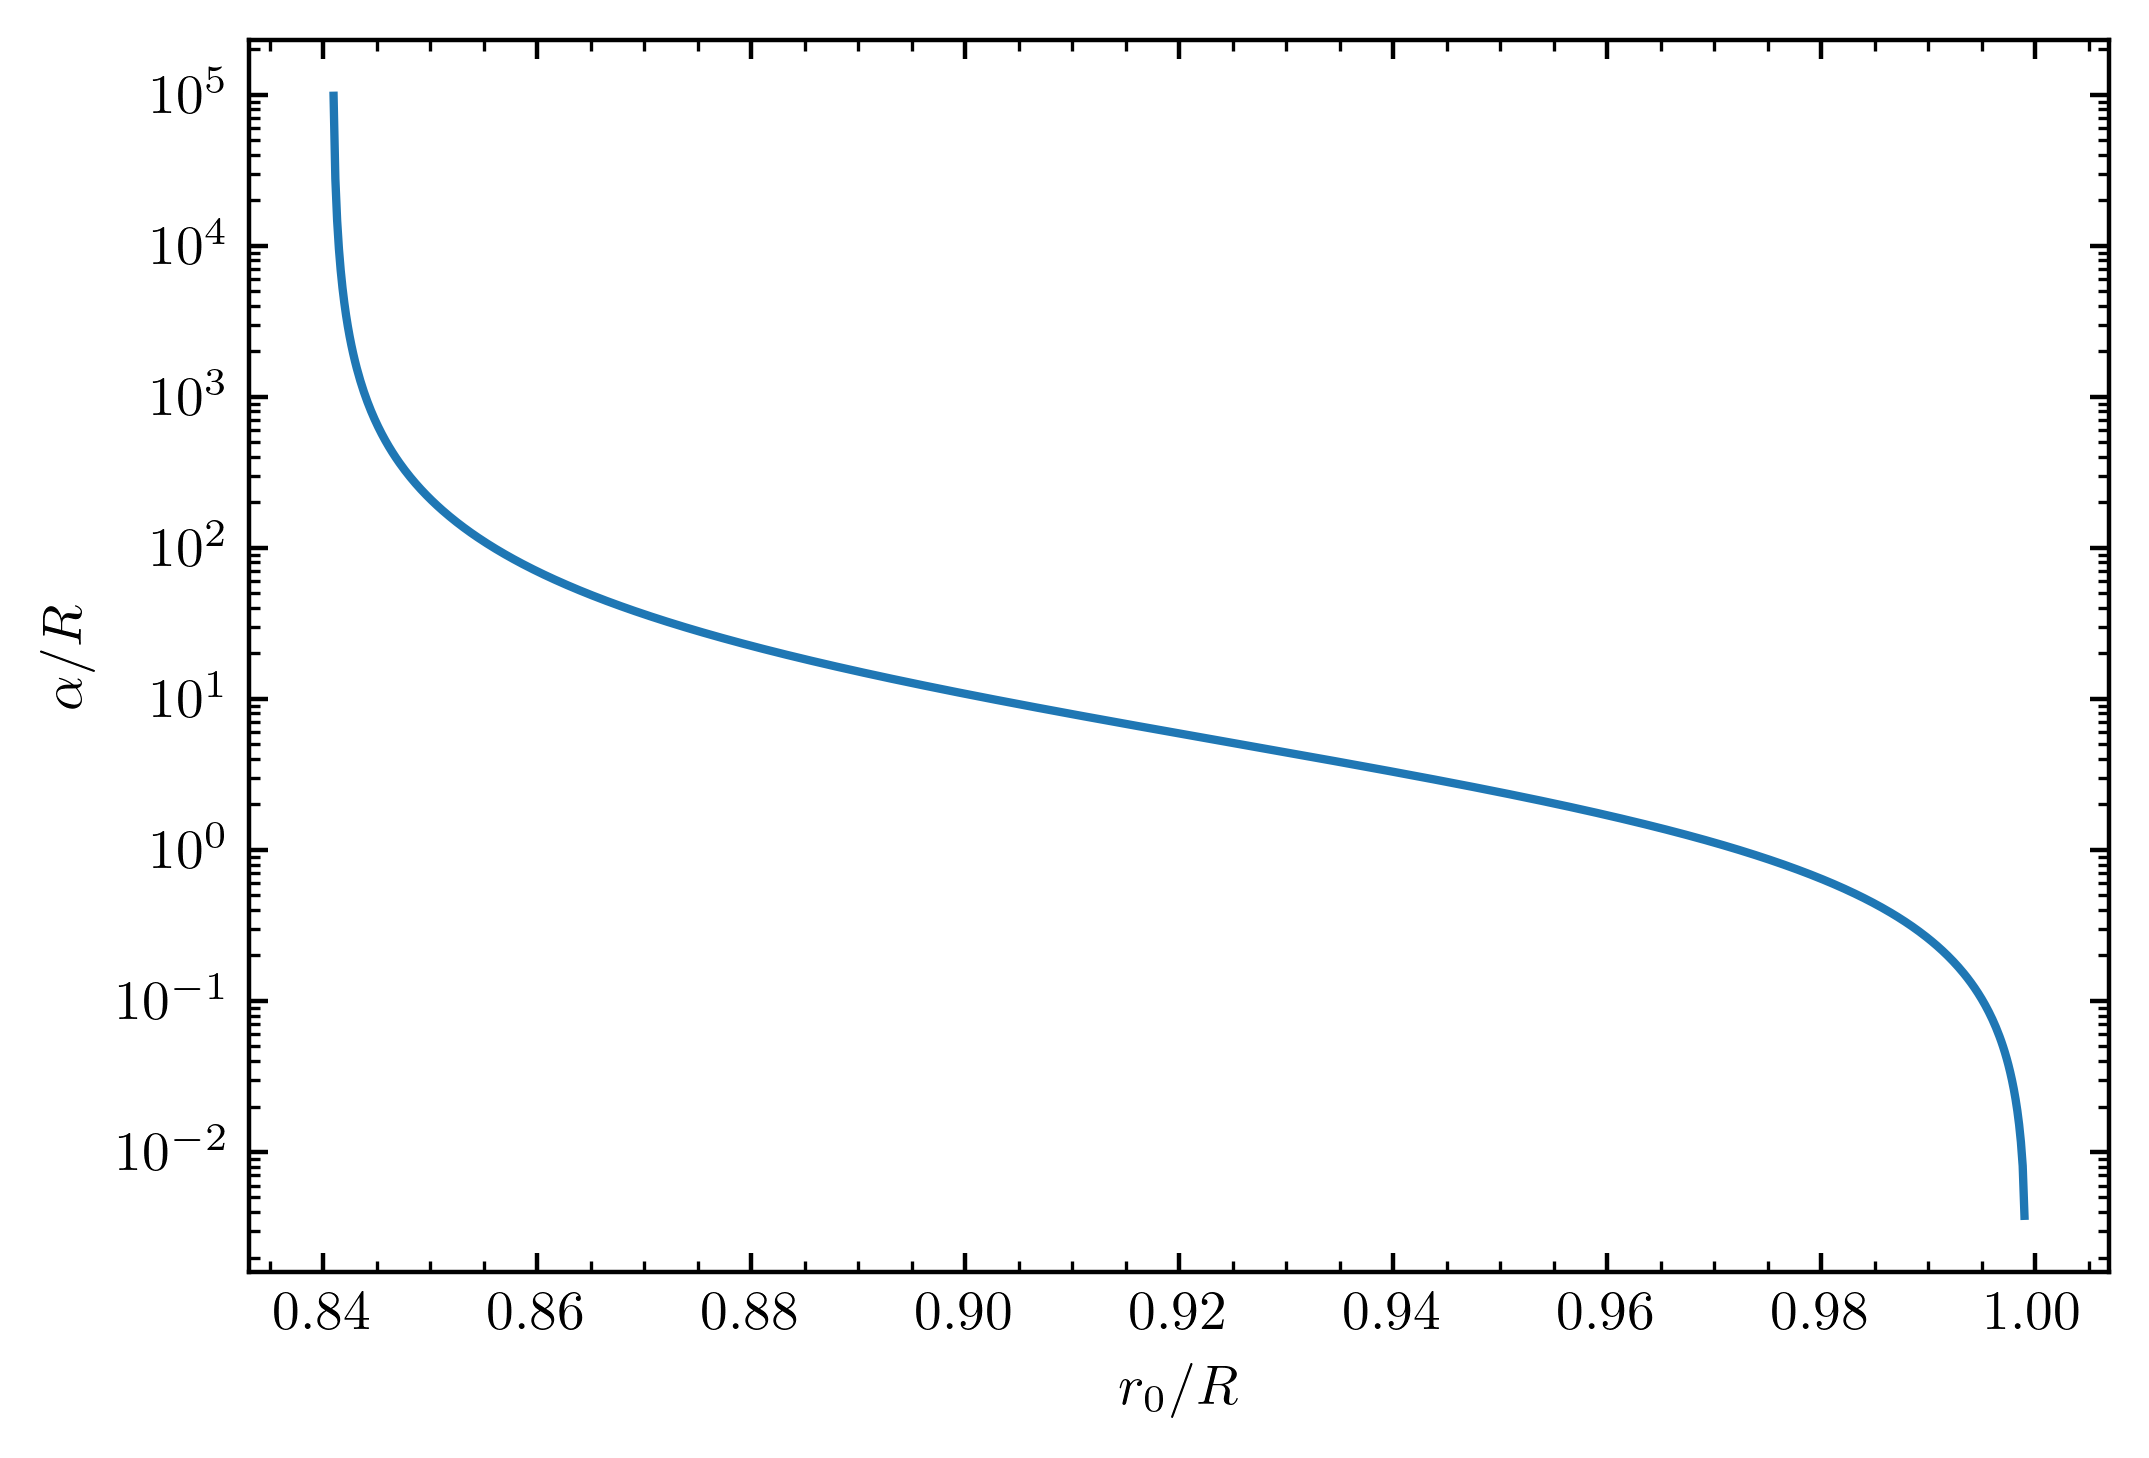

In [5]:
# plt.plot(r0grid[cmask],calphagrid[cmask],label='Commutative')
plt.plot(r0grid[ncmask],ncalphagrid[ncmask])#,label='Non-Commutative')
plt.xlabel(r"$r_0 / R$")
plt.ylabel(r'$\alpha / R$')
# plt.legend()
plt.semilogy()
# plt.show()
plt.savefig('combFigs/alphavsr0.pdf',format='pdf')

In [6]:
# normcalphagrid = calphagrid[cmask]/calphagrid[cmask].max()
# normncalphagrid = ncalphagrid[ncmask]/ncalphagrid[ncmask].max()

In [7]:
# plt.plot(r0grid[cmask],normcalphagrid,label='Commutative')
# plt.plot(r0grid[ncmask],normncalphagrid,label='Non-Commutative')
# plt.xlabel(r"$r_0 / R$")
# plt.ylabel(r'$\alpha / R$')
# plt.legend()
# plt.semilogy()
# # plt.savefig('combFigs/normalphavsr0.pdf',format='pdf')
# plt.show()

In [8]:
# careaInt = sf.shockArea(r0grid,R)
ncareaInt = nsf.shockArea(r0grid,R)

# cmask = careaInt > 0
ncmask = ncareaInt > 0

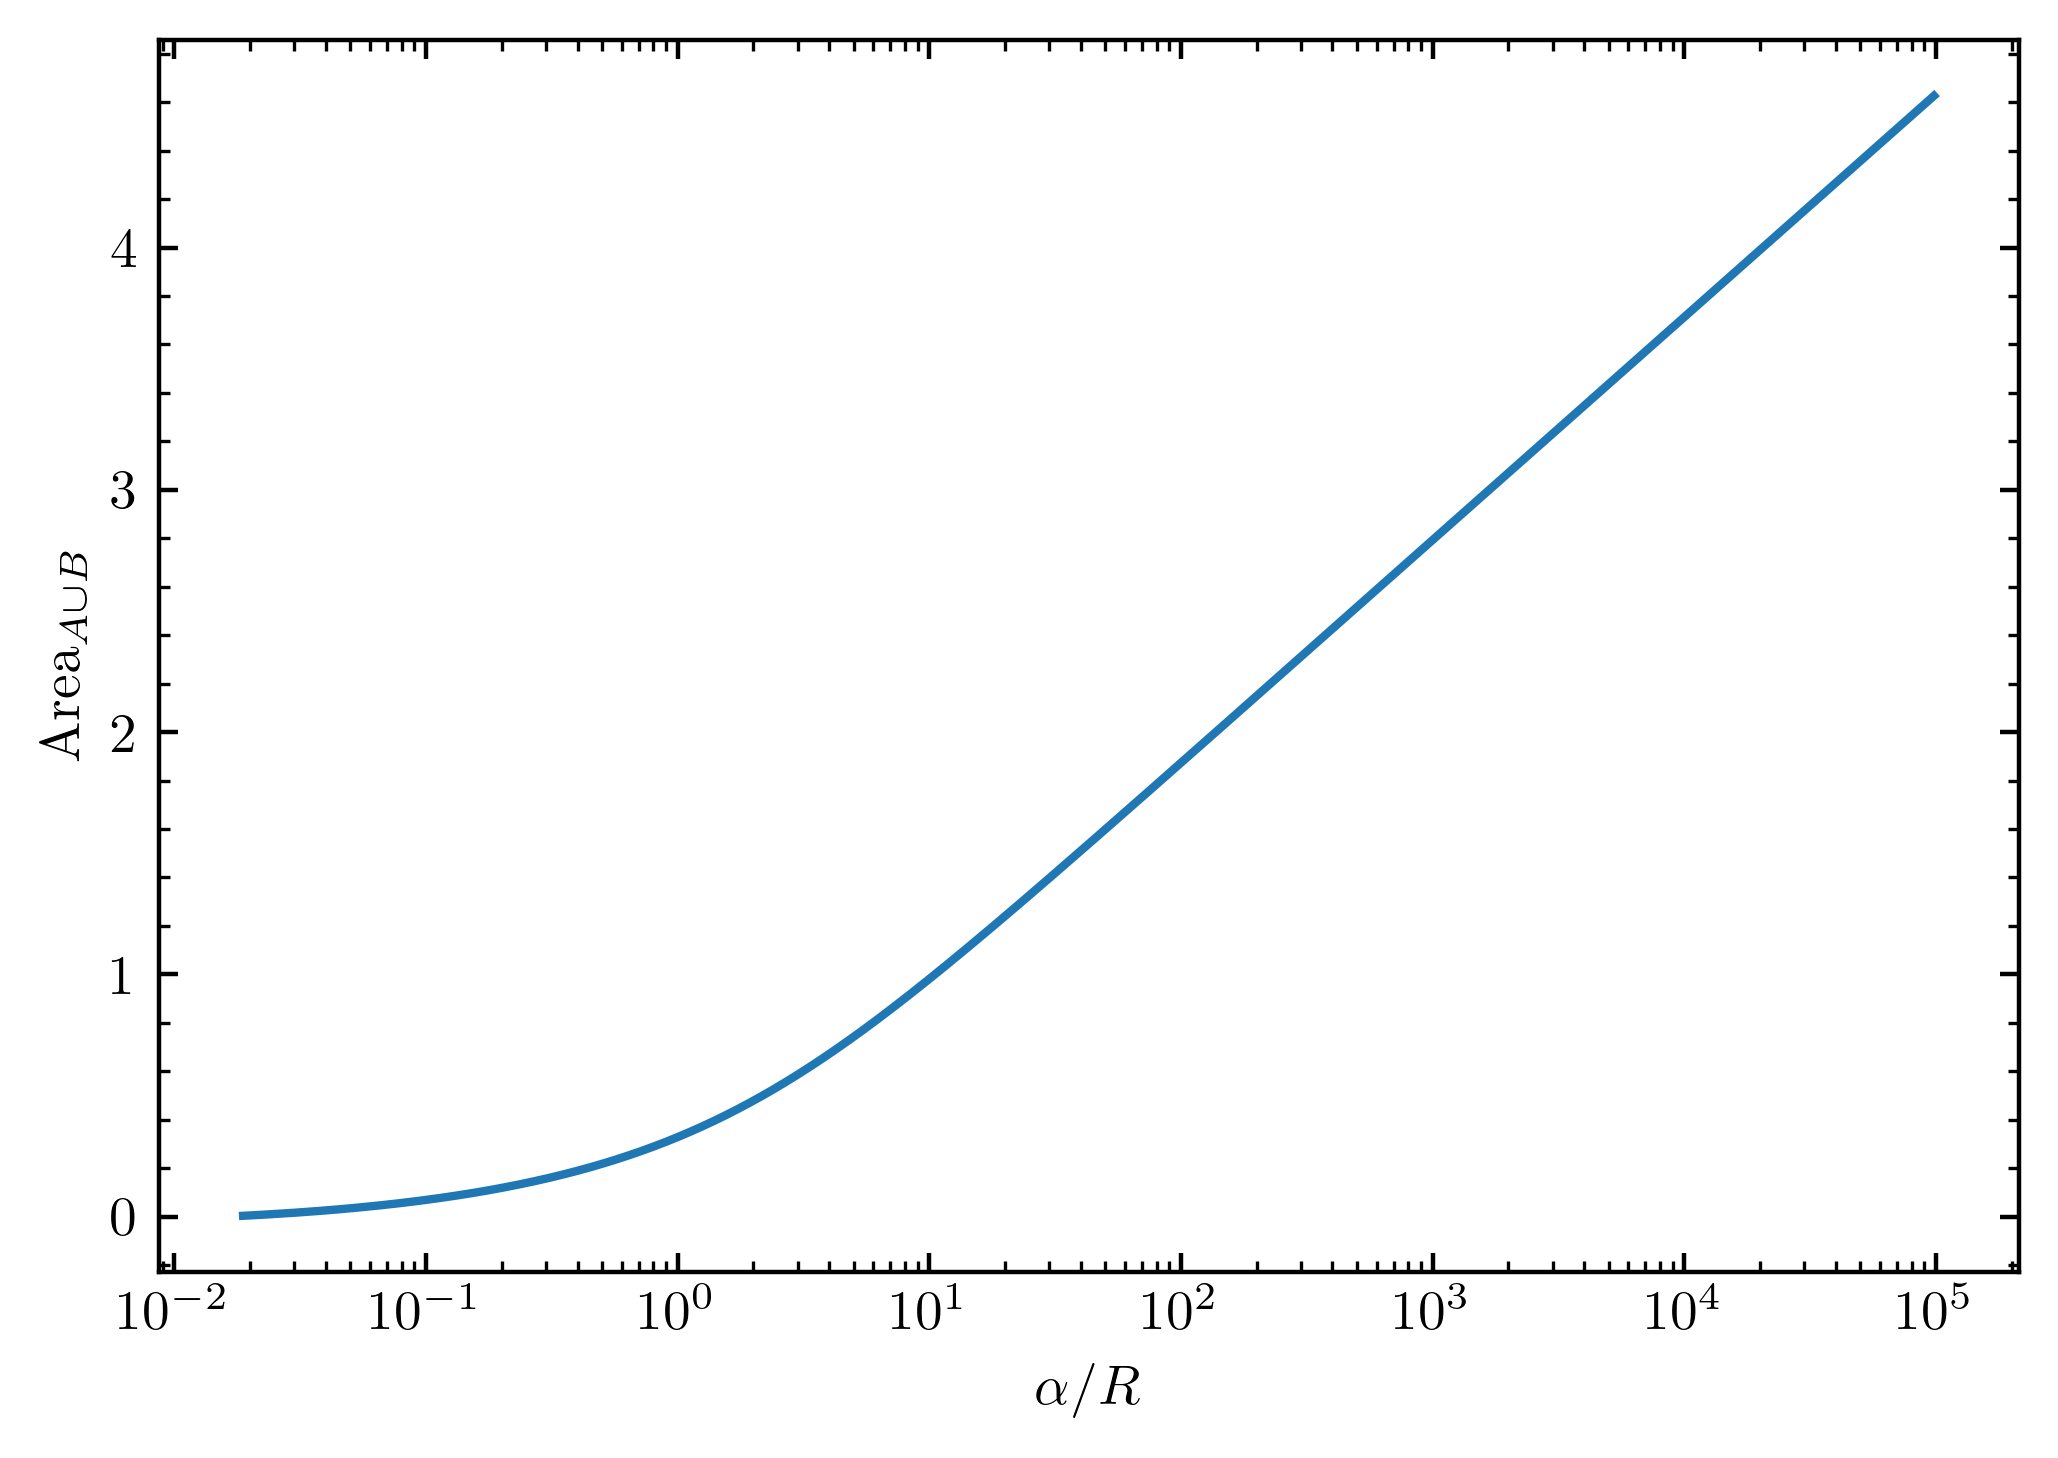

In [9]:
# plt.plot(calphagrid[cmask],careaInt[cmask],label='Commutative')
plt.plot(ncalphagrid[ncmask],ncareaInt[ncmask])#,label='Non-Commutative')
plt.semilogx()
# plt.semilogy()
# plt.legend()
# plt.xlim((min(ncalphagrid[ncmask].min(),calphagrid[cmask].min()),min(ncalphagrid[ncmask].max(),calphagrid[cmask].max())))
plt.xlabel(r'$\alpha / R$')
plt.ylabel(r'Area$_{A \cup B}$')
# plt.show()
plt.savefig('combFigs/shockAvsalpha.pdf',format='pdf')

In [10]:
rminarr = np.logspace(np.log10(R+eps),np.log10(min([nsf.rmax])),num)

# cLvsrminarr = sf.Lvsrmin(rminarr,R)
climLvsrminarr = nsf.Lvsrmin(rminarr,R,eps)
ncLvsrminarr = nsf.Lvsrmin(rminarr,R,0.1)
ncLvsrminarr2 = nsf.Lvsrmin(rminarr,R,0.2)
ncLvsrminarr3 = nsf.Lvsrmin(rminarr,R,0.3)

/Users/bkorotko03/Desktop/Holography/HoloProj/NCShockFunc260331.py:133: RuntimeWarning: divide by zero encountered in divide
  integ = 2/np.sqrt((rarr**4) * f(rarr,R) * h(rarr,a) * b(rarr,rmin))


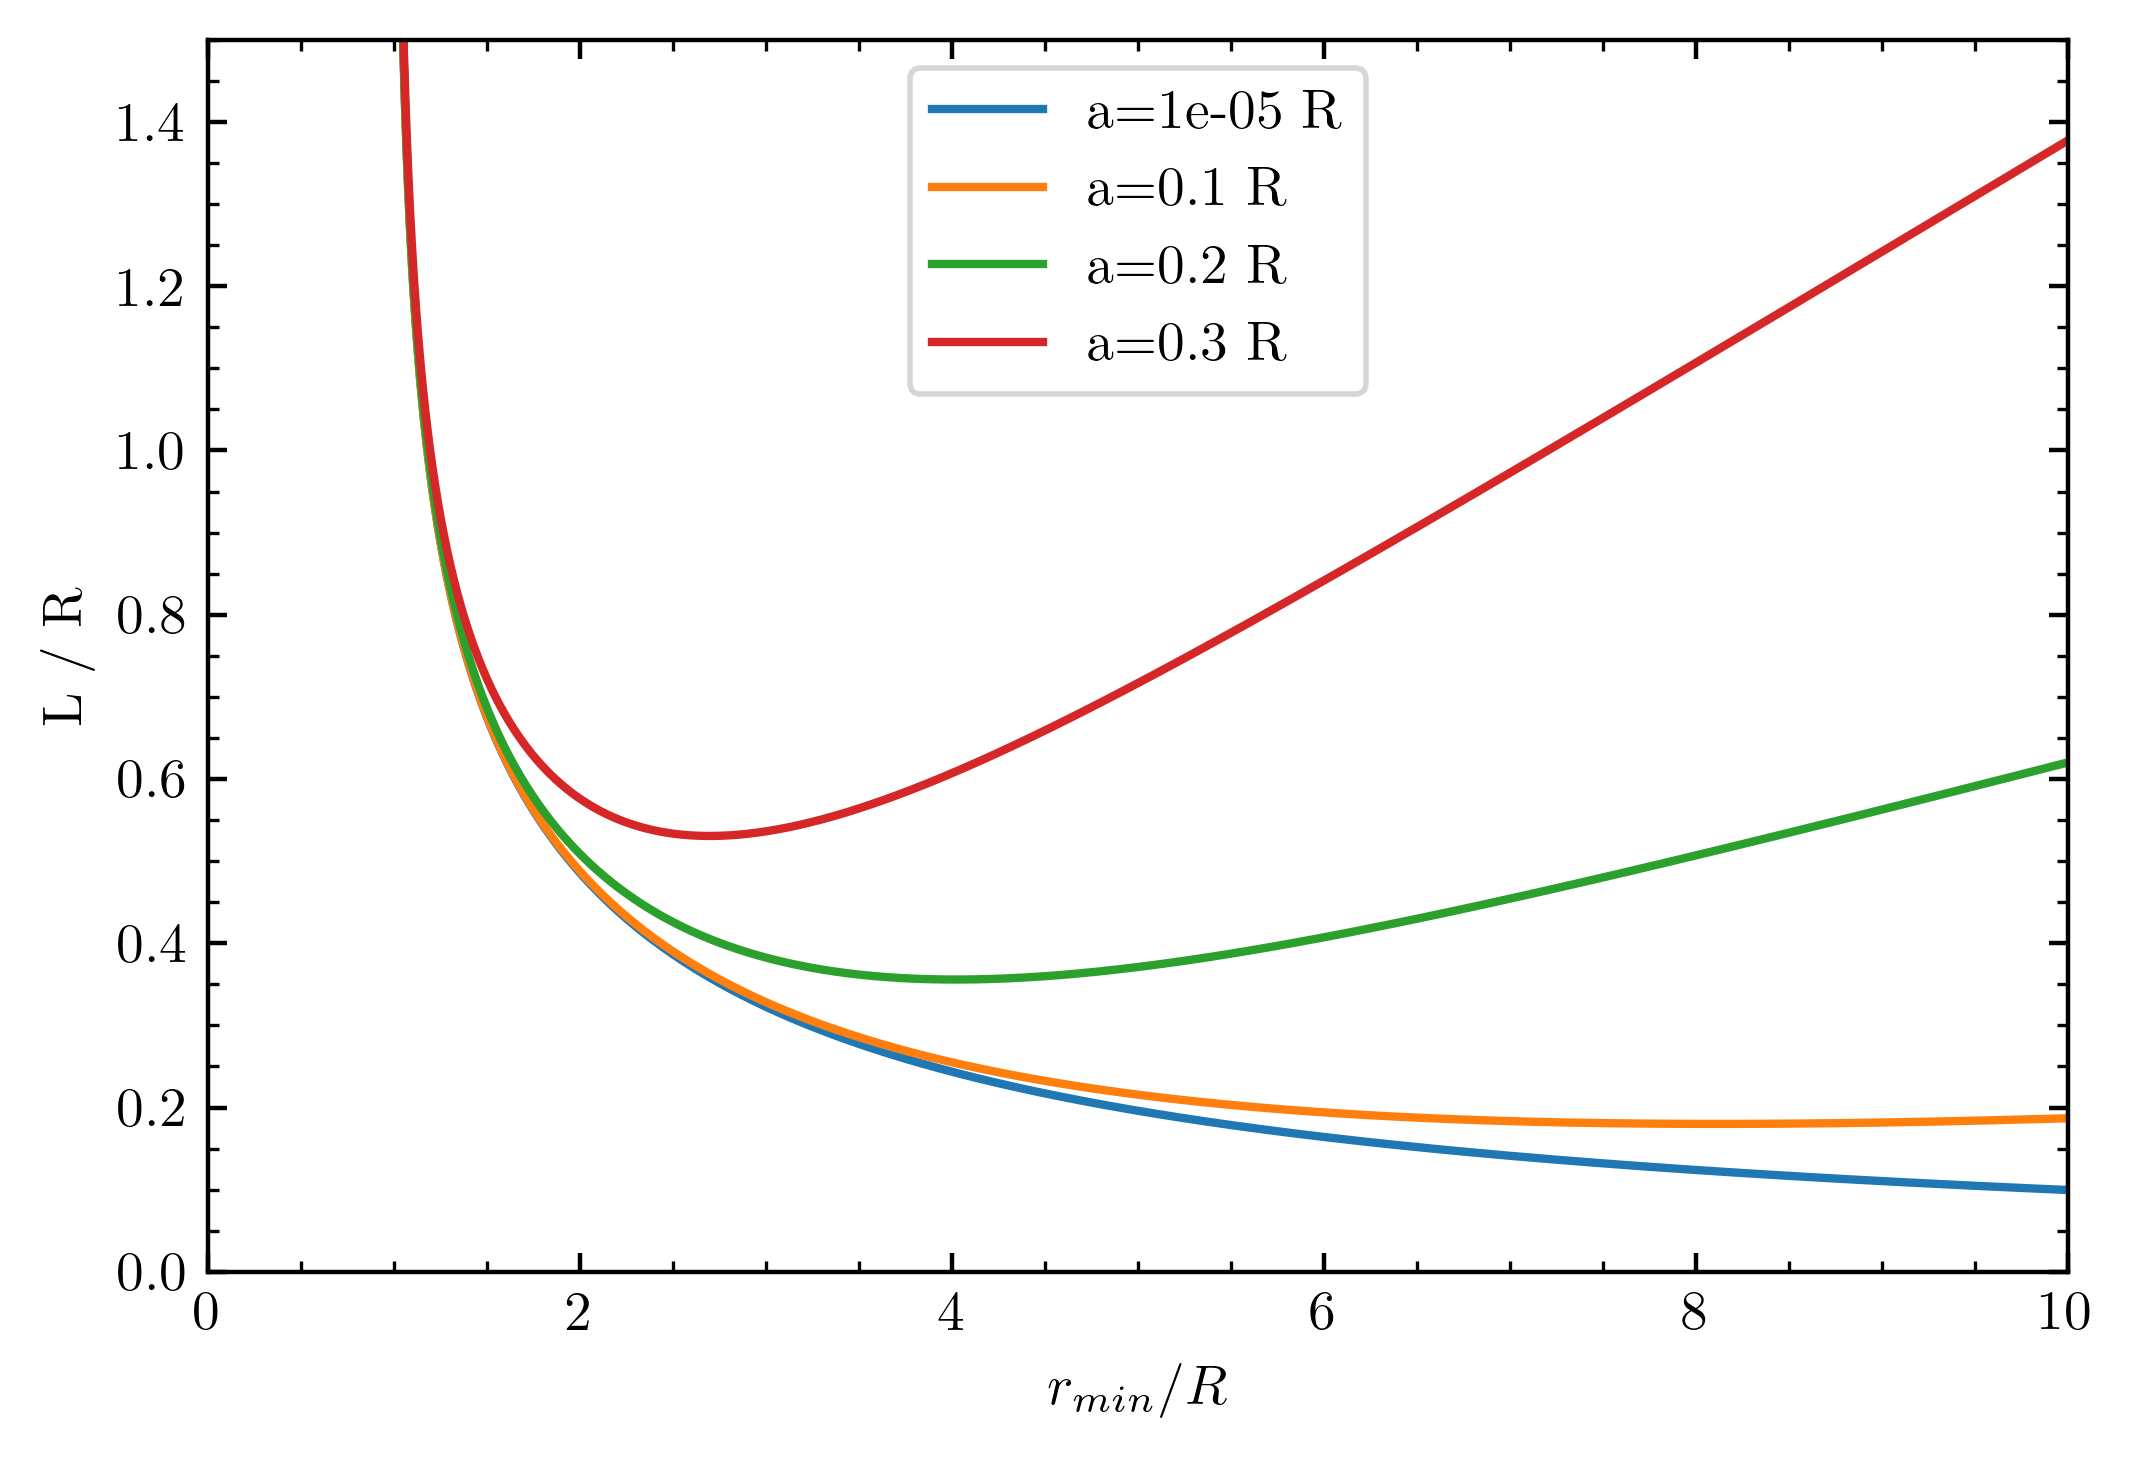

In [11]:
# plt.plot(rminarr,cLvsrminarr,label='a=0')
plt.plot(rminarr,climLvsrminarr,label=f'a={eps} R')
plt.plot(rminarr,ncLvsrminarr,label='a=0.1 R')
plt.plot(rminarr,ncLvsrminarr2,label='a=0.2 R')
plt.plot(rminarr,ncLvsrminarr3,label='a=0.3 R')
plt.xlim((0,rminarr.max()/10))
plt.ylim((0,1.5))
plt.xlabel(r'$r_{min} / R$')
plt.ylabel(r'L / R')
# plt.semilogy()
plt.legend()
# plt.show()
plt.savefig('combFigs/Lvsrmin.pdf',format='pdf')

In [12]:
adjclimrmin = nsf.rMinCutoff(rminarr,climLvsrminarr)
adjrminarr = nsf.rMinCutoff(rminarr,ncLvsrminarr)
adjrminarr2 = nsf.rMinCutoff(rminarr,ncLvsrminarr2)
adjrminarr3 = nsf.rMinCutoff(rminarr,ncLvsrminarr3)

In [13]:
adjclimLvsrmin = nsf.Lvsrmin(adjclimrmin,R,eps)
adjncLvsrminarr = nsf.Lvsrmin(adjrminarr,R,0.1)
adjncLvsrminarr2 = nsf.Lvsrmin(adjrminarr2,R,0.2)
adjncLvsrminarr3 = nsf.Lvsrmin(adjrminarr3,R,0.3)

In [14]:
# cunArea = sf.unAreaInt(rminarr,R)
climunArea = nsf.unAreaInt(adjclimrmin,R,eps)
ncunArea = nsf.unAreaInt(adjrminarr,R,0.1)
ncunArea2 = nsf.unAreaInt(adjrminarr2,R,0.2)
ncunArea3 = nsf.unAreaInt(adjrminarr3,R,0.3)

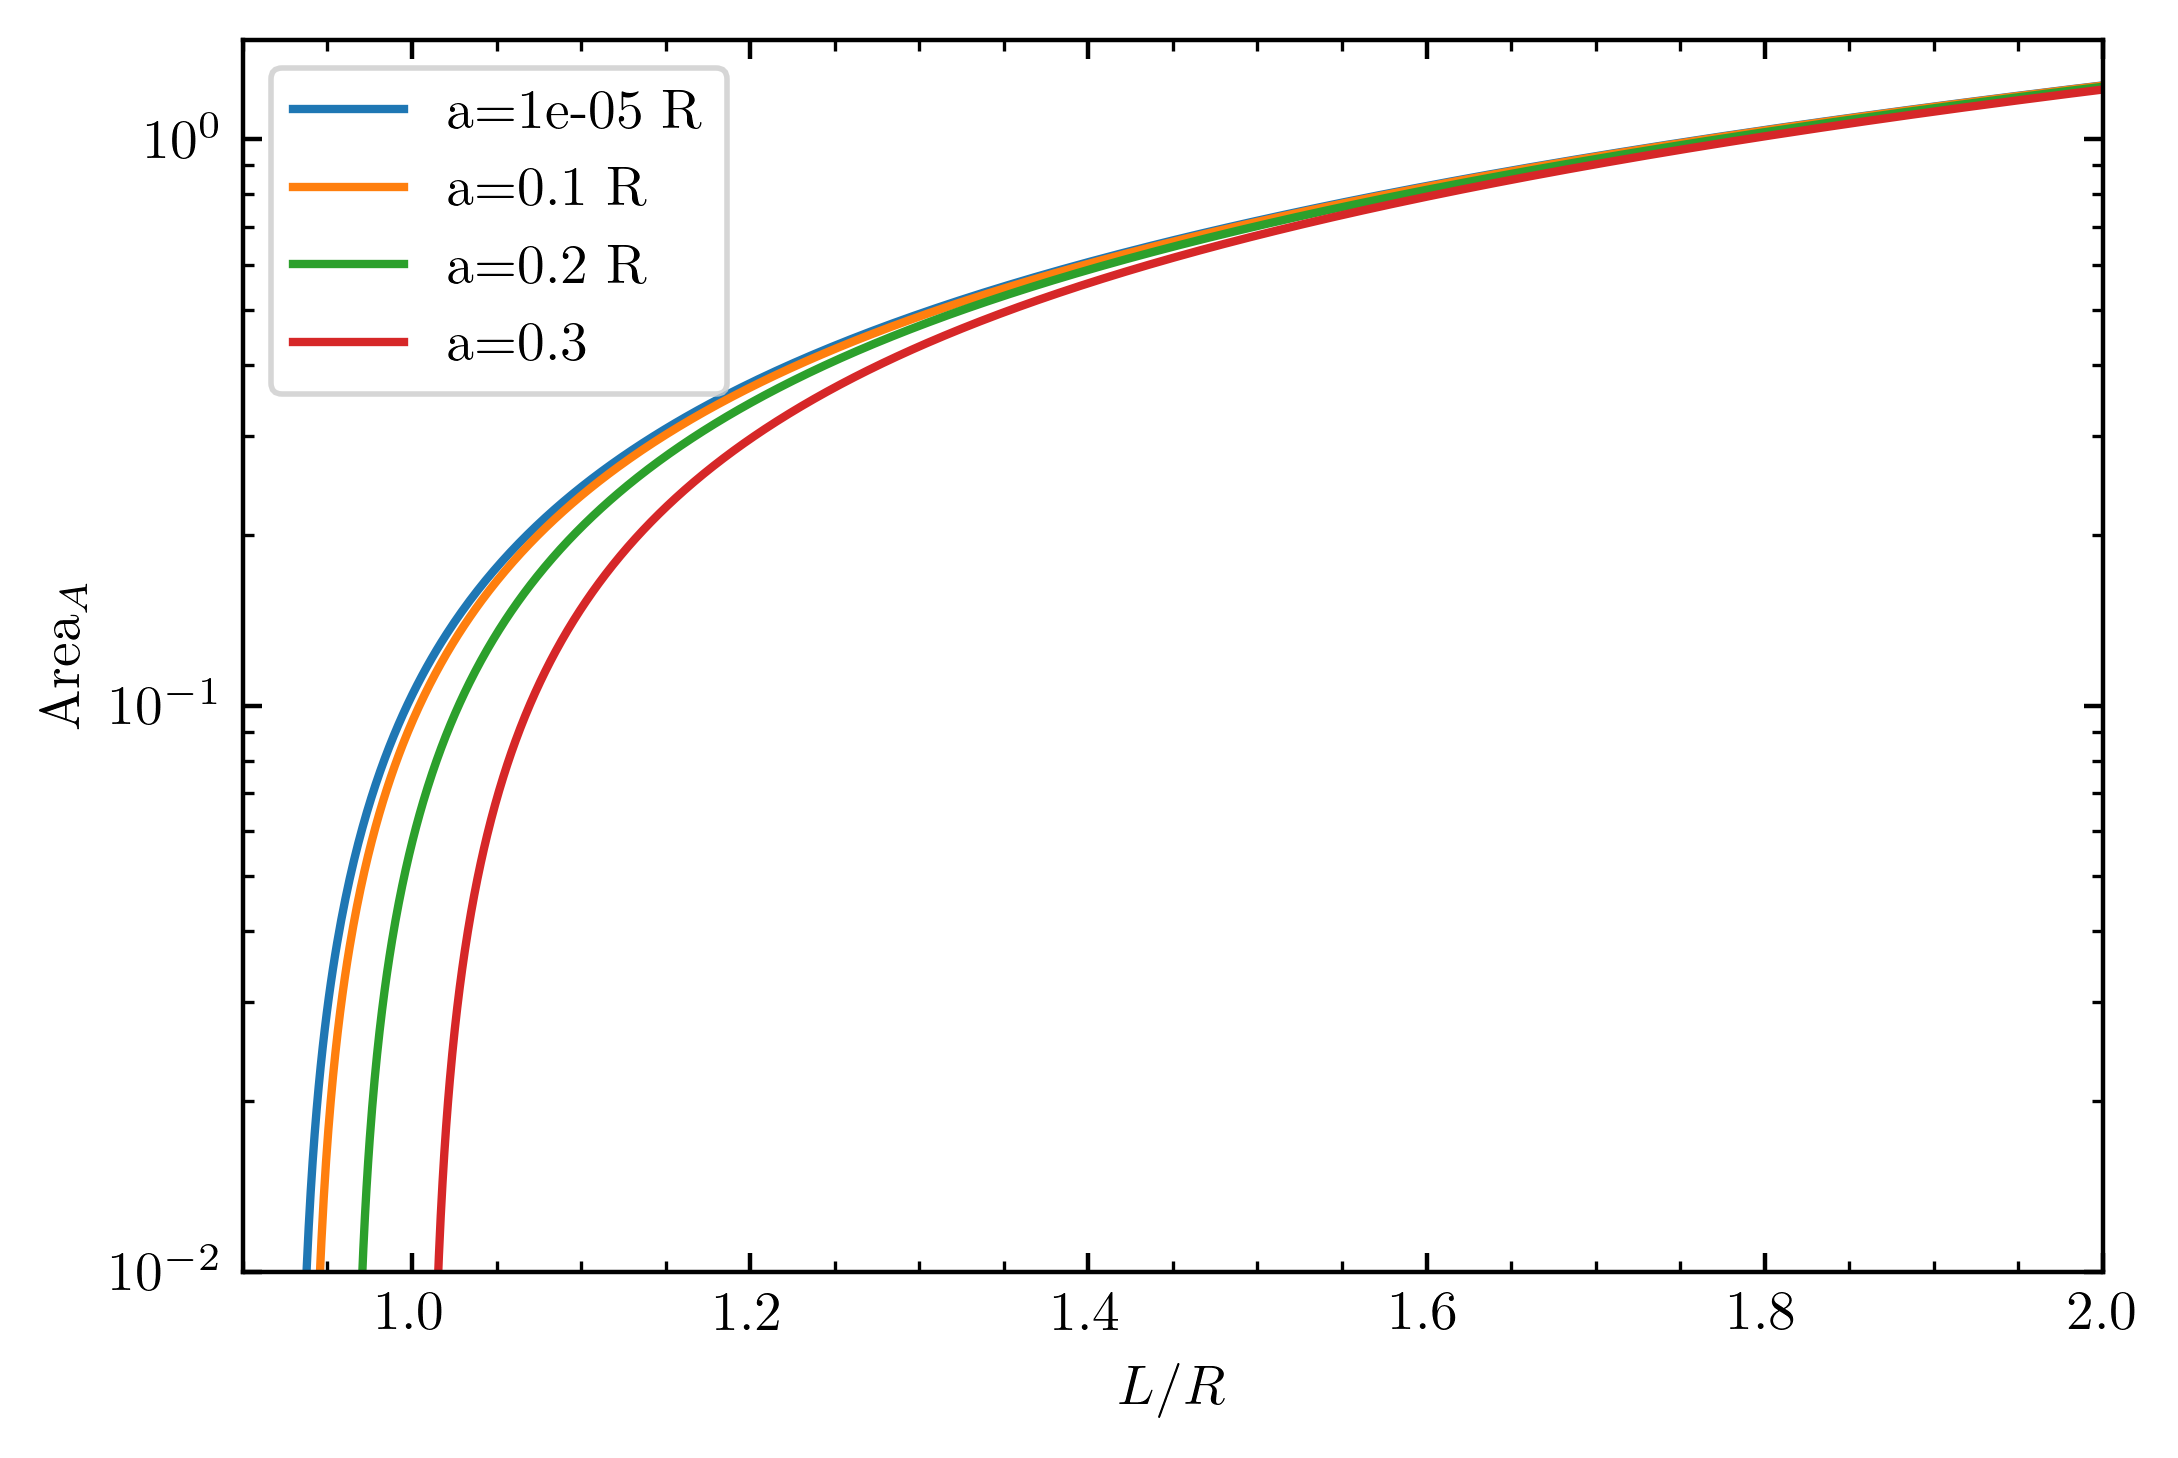

In [15]:
# plt.plot(cLvsrminarr,cunArea,label='a=0')
plt.plot(adjclimLvsrmin,climunArea,label=f'a={eps} R')
plt.plot(adjncLvsrminarr,ncunArea,label='a=0.1 R')
plt.plot(adjncLvsrminarr2,ncunArea2,label='a=0.2 R')
plt.plot(adjncLvsrminarr3,ncunArea3,label='a=0.3')
plt.legend()
plt.semilogy()
# plt.semilogx()
plt.xlabel(r'$ L / R$')
plt.ylabel(r'Area$_A$')
plt.ylim((0.01,1.5))
plt.xlim((0.9,2))
# plt.show()
plt.savefig('combFigs/unArea.pdf',format='pdf')

In [25]:
print(ncunArea[150],ncunArea2[150],ncunArea3[150])

0.6830437767202966 0.8808467052876949 1.055065087042749


In [27]:
print(adjclimLvsrmin[150],adjncLvsrminarr[150],adjncLvsrminarr2[150],adjncLvsrminarr3[150])

1.2311177424772632 1.4708782818612989 1.6605759478674662 1.8391802545475675


In [31]:
# np.searchsorted(adjclimLvsrmin,1.5)
np.abs(adjclimLvsrmin - 1.5).argmin()

np.int64(80)

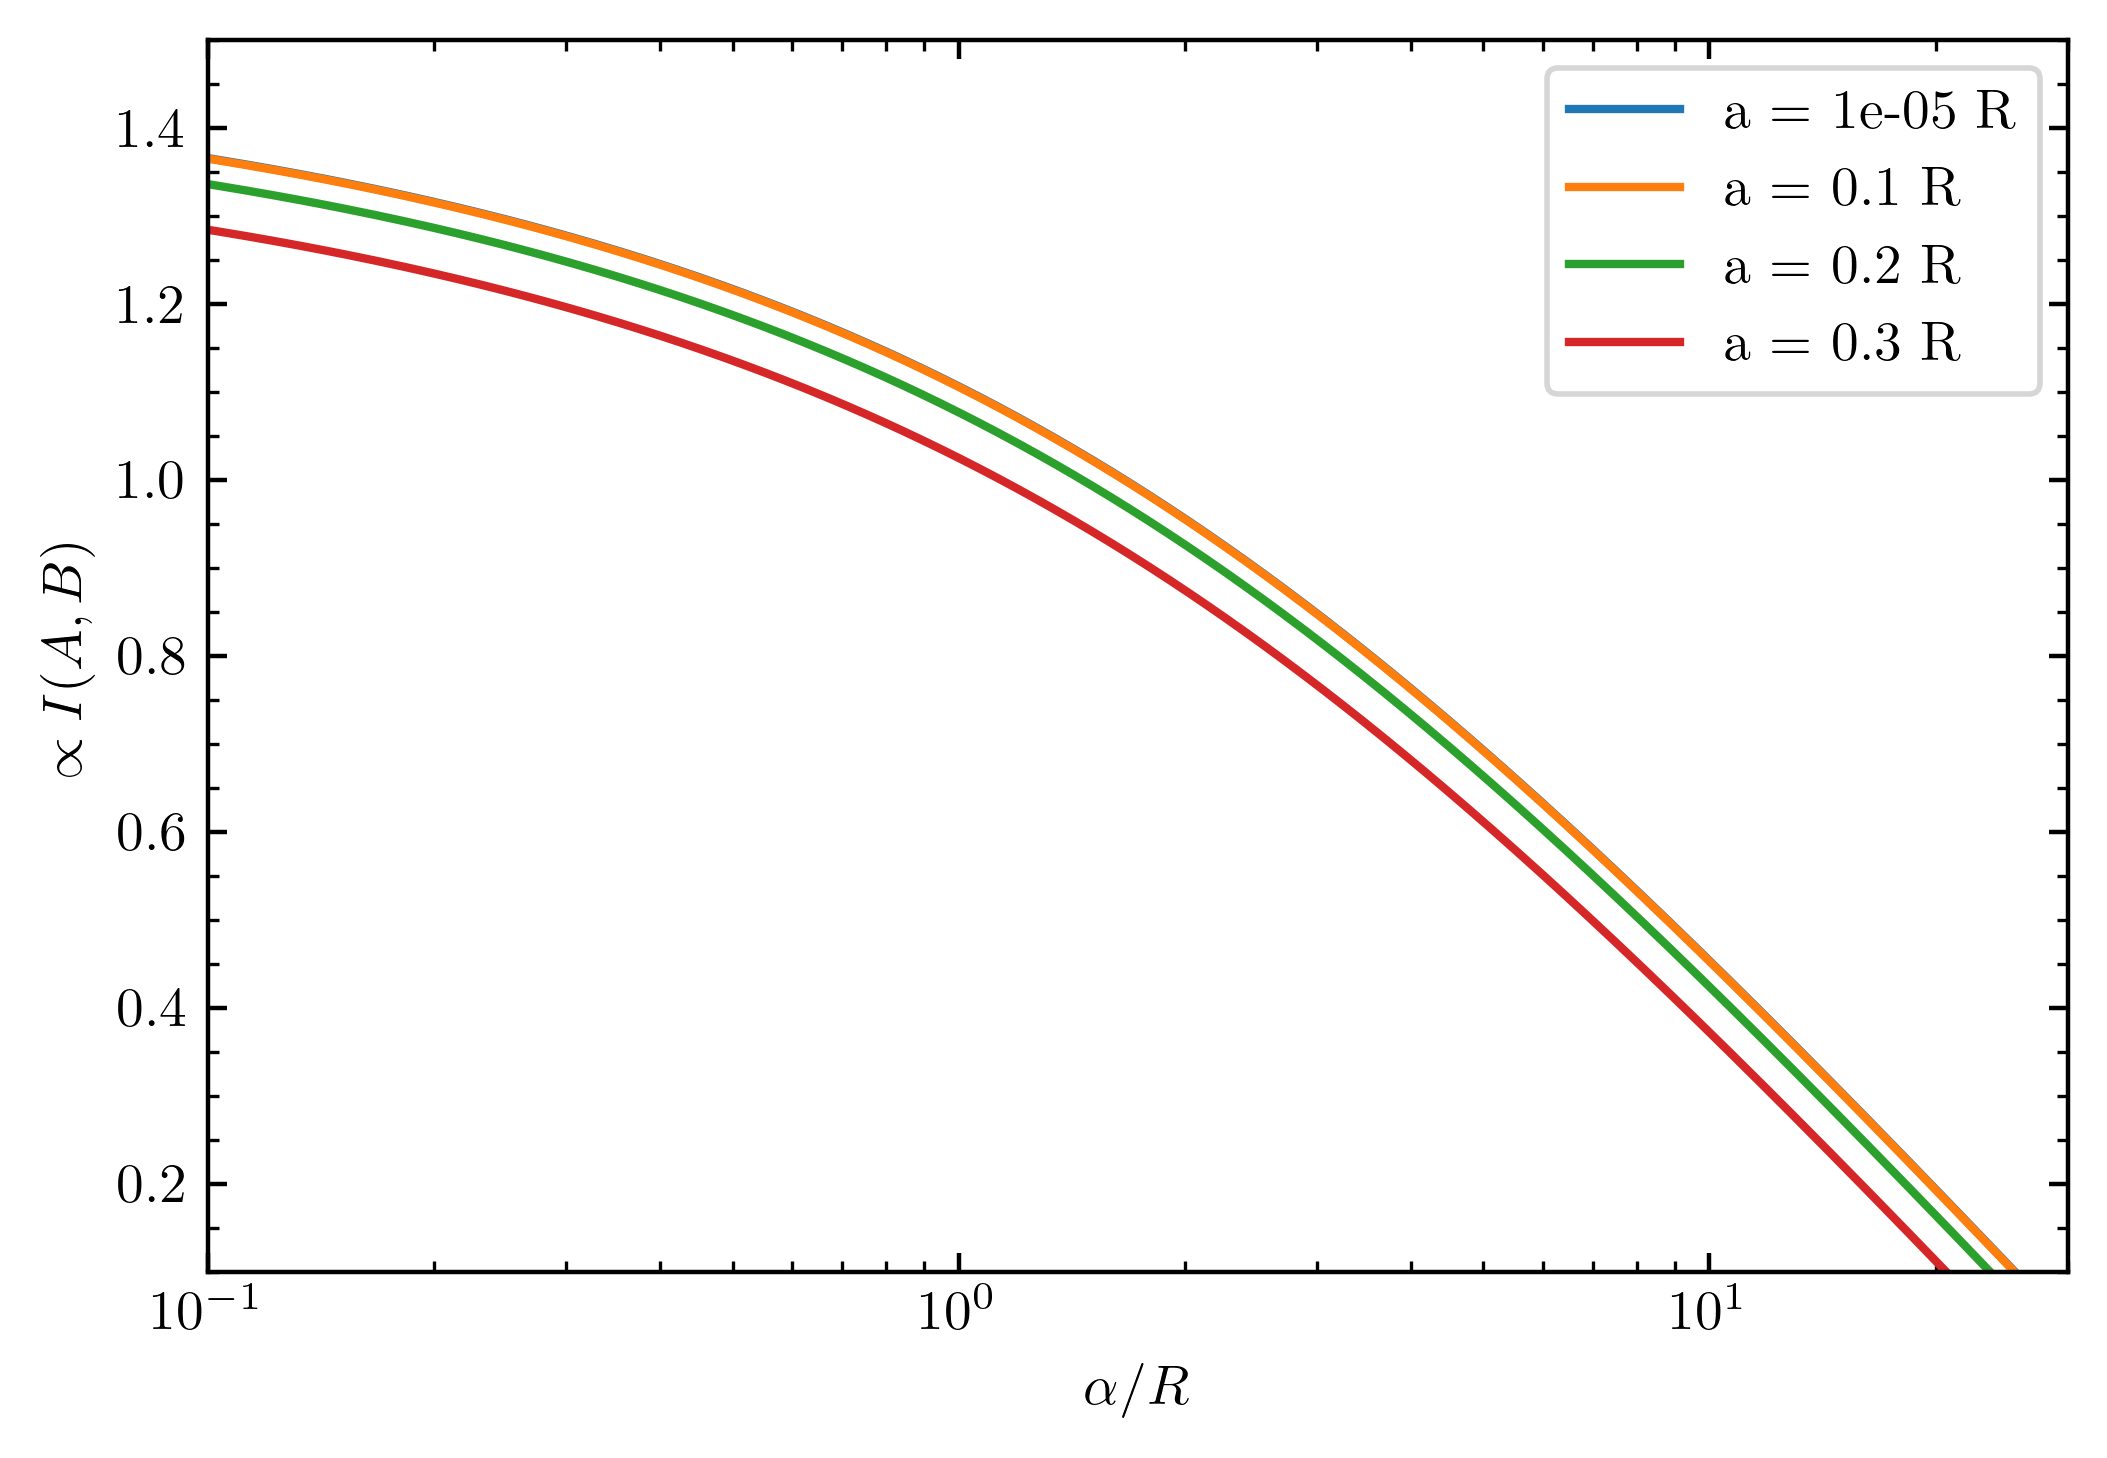

In [94]:
pickL = 1.5
cidx = np.abs(adjclimLvsrmin - pickL).argmin()
ncidx = np.abs(adjncLvsrminarr - pickL).argmin()
ncidx2 = np.abs(adjncLvsrminarr2 - pickL).argmin()
ncidx3 = np.abs(adjncLvsrminarr3 - pickL).argmin()
idx = 150
# cMutInf = 2*cunArea[idx] - careaInt[cmask]
climMutInf = 2*climunArea[cidx] - ncareaInt[ncmask]
ncMutInf = 2*ncunArea[ncidx] - ncareaInt[ncmask]
ncMutInf2 = 2*ncunArea2[ncidx2] - ncareaInt[ncmask]
ncMutInf3 = 2*ncunArea3[ncidx3] - ncareaInt[ncmask]
# plt.plot(calphagrid[cmask],cMutInf,label=r'a = 0')
plt.plot(ncalphagrid[ncmask],climMutInf,label=f'a = {eps} R')
plt.plot(ncalphagrid[ncmask],ncMutInf,label=r'a = 0.1 R')
plt.plot(ncalphagrid[ncmask],ncMutInf2,label=r'a = 0.2 R')
plt.plot(ncalphagrid[ncmask],ncMutInf3,label=r'a = 0.3 R')
plt.ylim(0.1,1.5)
plt.xlim(0.1,30)
plt.ylabel(r'$\propto I(A,B)$')
plt.xlabel(r'$\alpha / R$')
plt.semilogx()
# plt.semilogy()
plt.legend()
# plt.savefig('combFigs/mutInf.pdf',format='pdf')
plt.show()

In [95]:
(climMutInf - ncMutInf).max()

np.float64(0.0006515967506857123)

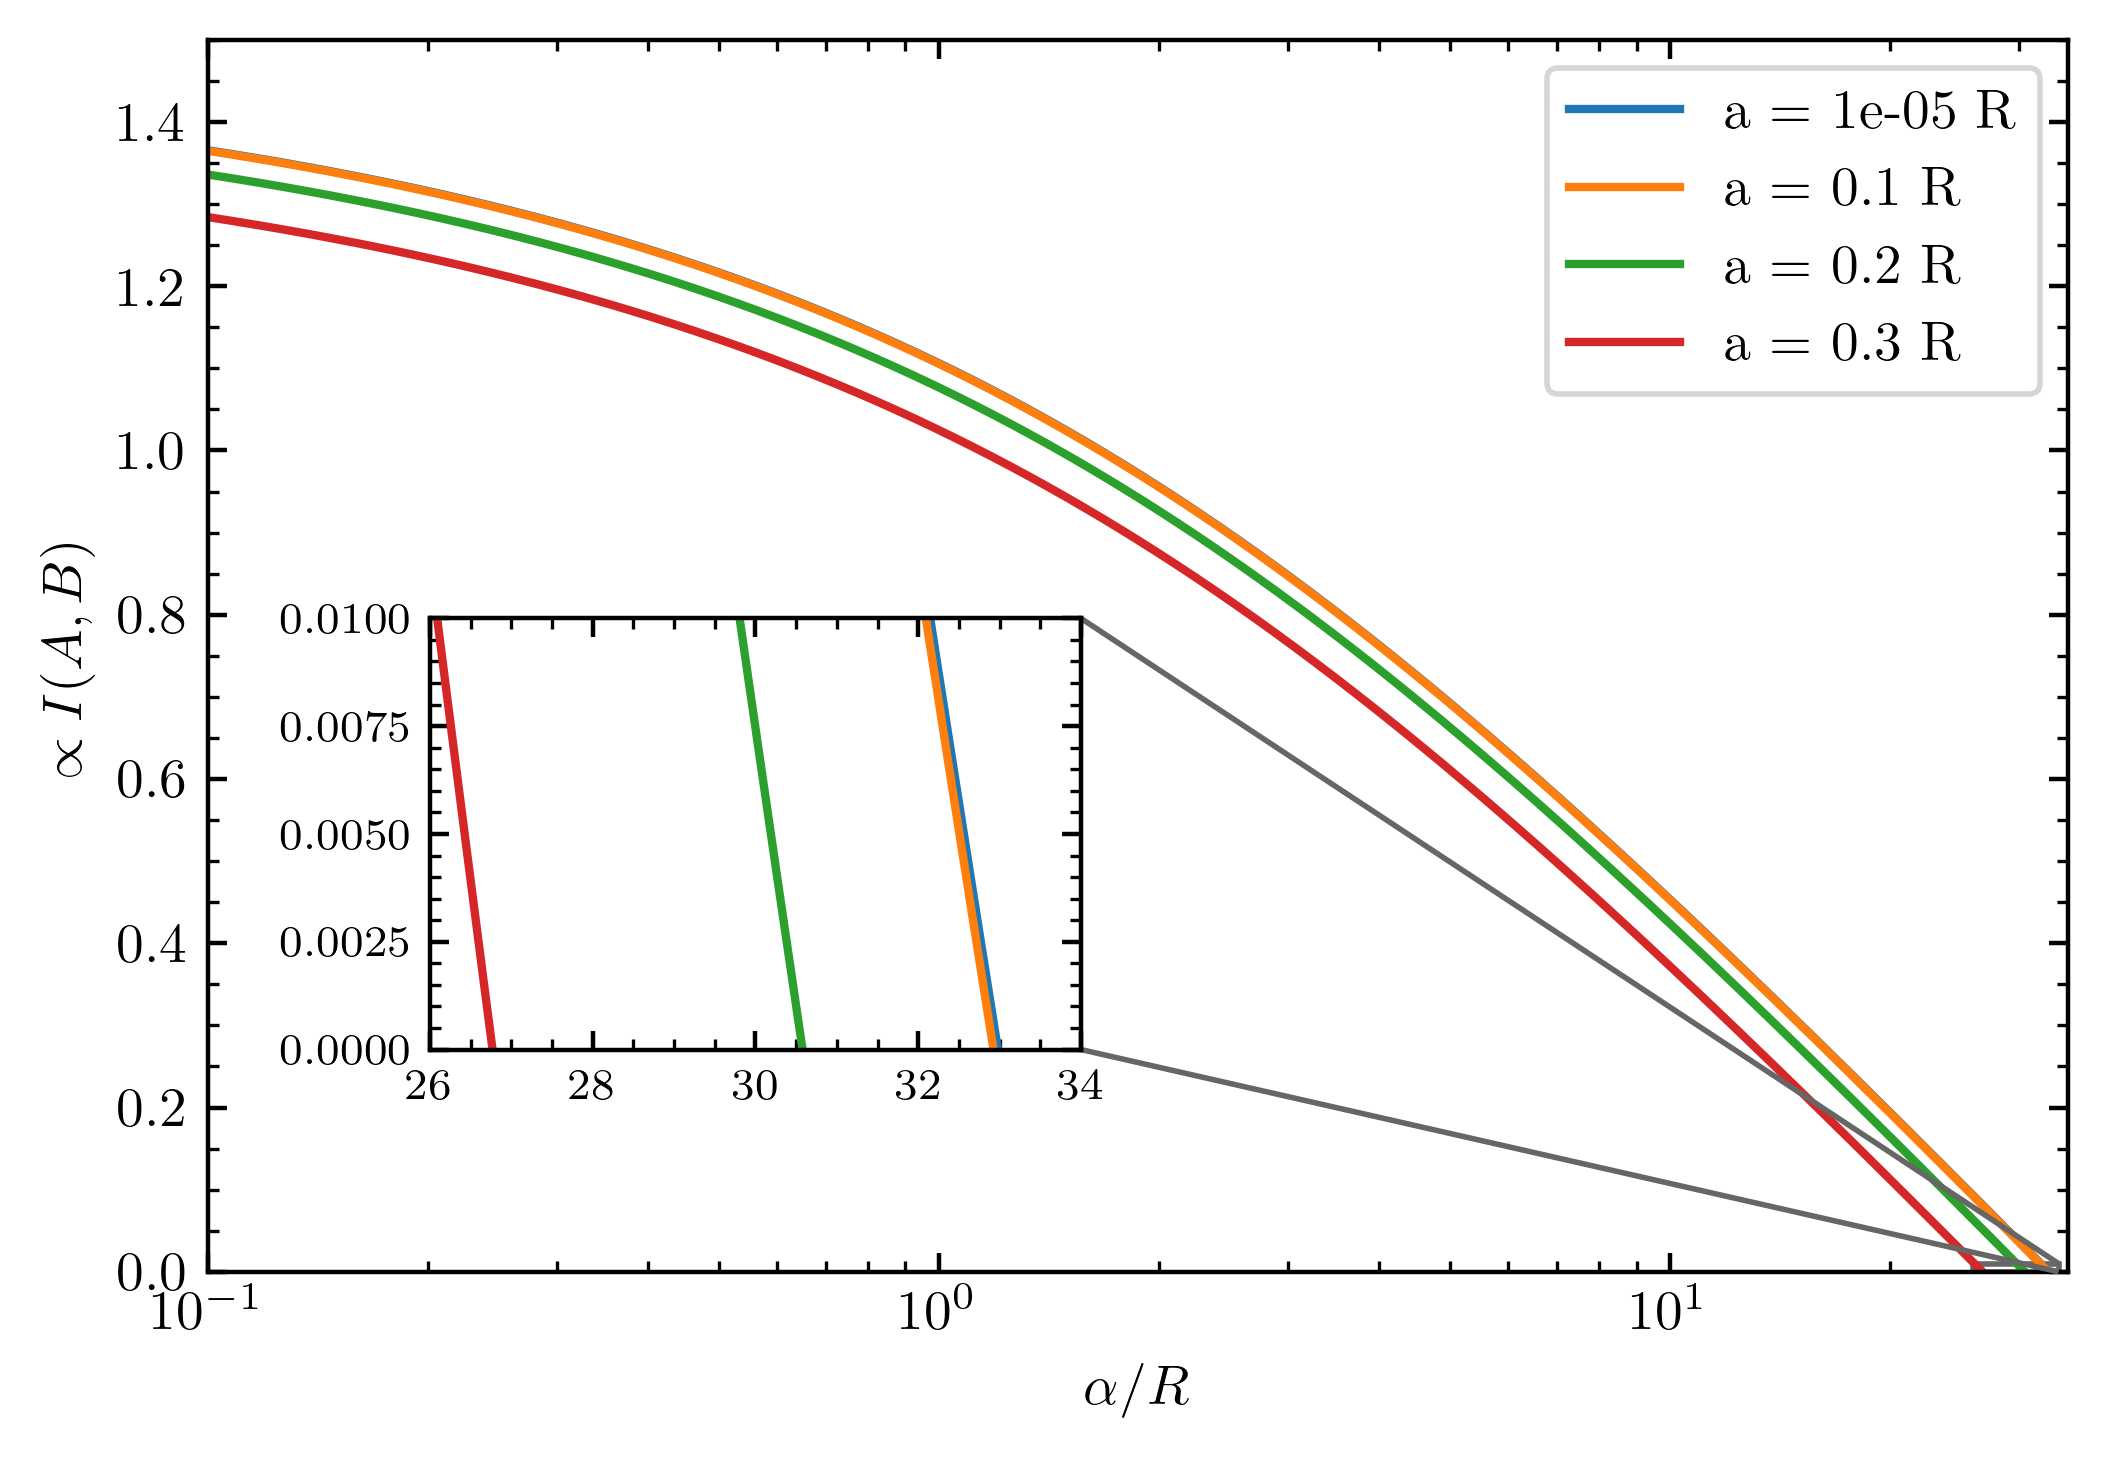

In [96]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

fig, ax = plt.subplots()

# Main plot
ax.plot(ncalphagrid[ncmask], climMutInf, label=f'a = {eps} R')
ax.plot(ncalphagrid[ncmask], ncMutInf, label=r'a = 0.1 R')
ax.plot(ncalphagrid[ncmask], ncMutInf2, label=r'a = 0.2 R')
ax.plot(ncalphagrid[ncmask], ncMutInf3, label=r'a = 0.3 R')
ax.set_ylim(0, 1.5)
ax.set_xlim(0.1, 35)
ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_ylabel(r'$\propto I(A,B)$')
ax.set_xlabel(r'$\alpha / R$')
ax.legend()

# Inset (zoomed region)
axins = inset_axes(ax, width="35%", height="35%", loc="lower left", borderpad=4)
axins.plot(ncalphagrid[ncmask], climMutInf)
axins.plot(ncalphagrid[ncmask], ncMutInf)
axins.plot(ncalphagrid[ncmask], ncMutInf2)
axins.plot(ncalphagrid[ncmask], ncMutInf3)
# axins.set_xscale('log')
# axins.set_yscale('log')

# Pick your zoom window here:
axins.set_xlim(26,34)
axins.set_ylim(0, 0.01)

axins.tick_params(labelsize=8)
mark_inset(ax, axins, loc1=1, loc2=4, fc="none", ec="0.4")

fig.savefig('combFigs/mutInf.pdf', format='pdf')
# plt.show()

In [17]:
# cLCArr = sf.LCritFunc(cLvsrminarr,calphagrid[cmask],cunArea,careaInt[cmask])
climLCArr = nsf.LCritFunc(adjclimLvsrmin,ncalphagrid[ncmask],climunArea,ncareaInt[ncmask])
ncLCArr = nsf.LCritFunc(adjncLvsrminarr,ncalphagrid[ncmask],ncunArea,ncareaInt[ncmask])
ncLCArr2 = nsf.LCritFunc(adjncLvsrminarr2,ncalphagrid[ncmask],ncunArea2,ncareaInt[ncmask])
ncLCArr3 = nsf.LCritFunc(adjncLvsrminarr3,ncalphagrid[ncmask],ncunArea3,ncareaInt[ncmask])

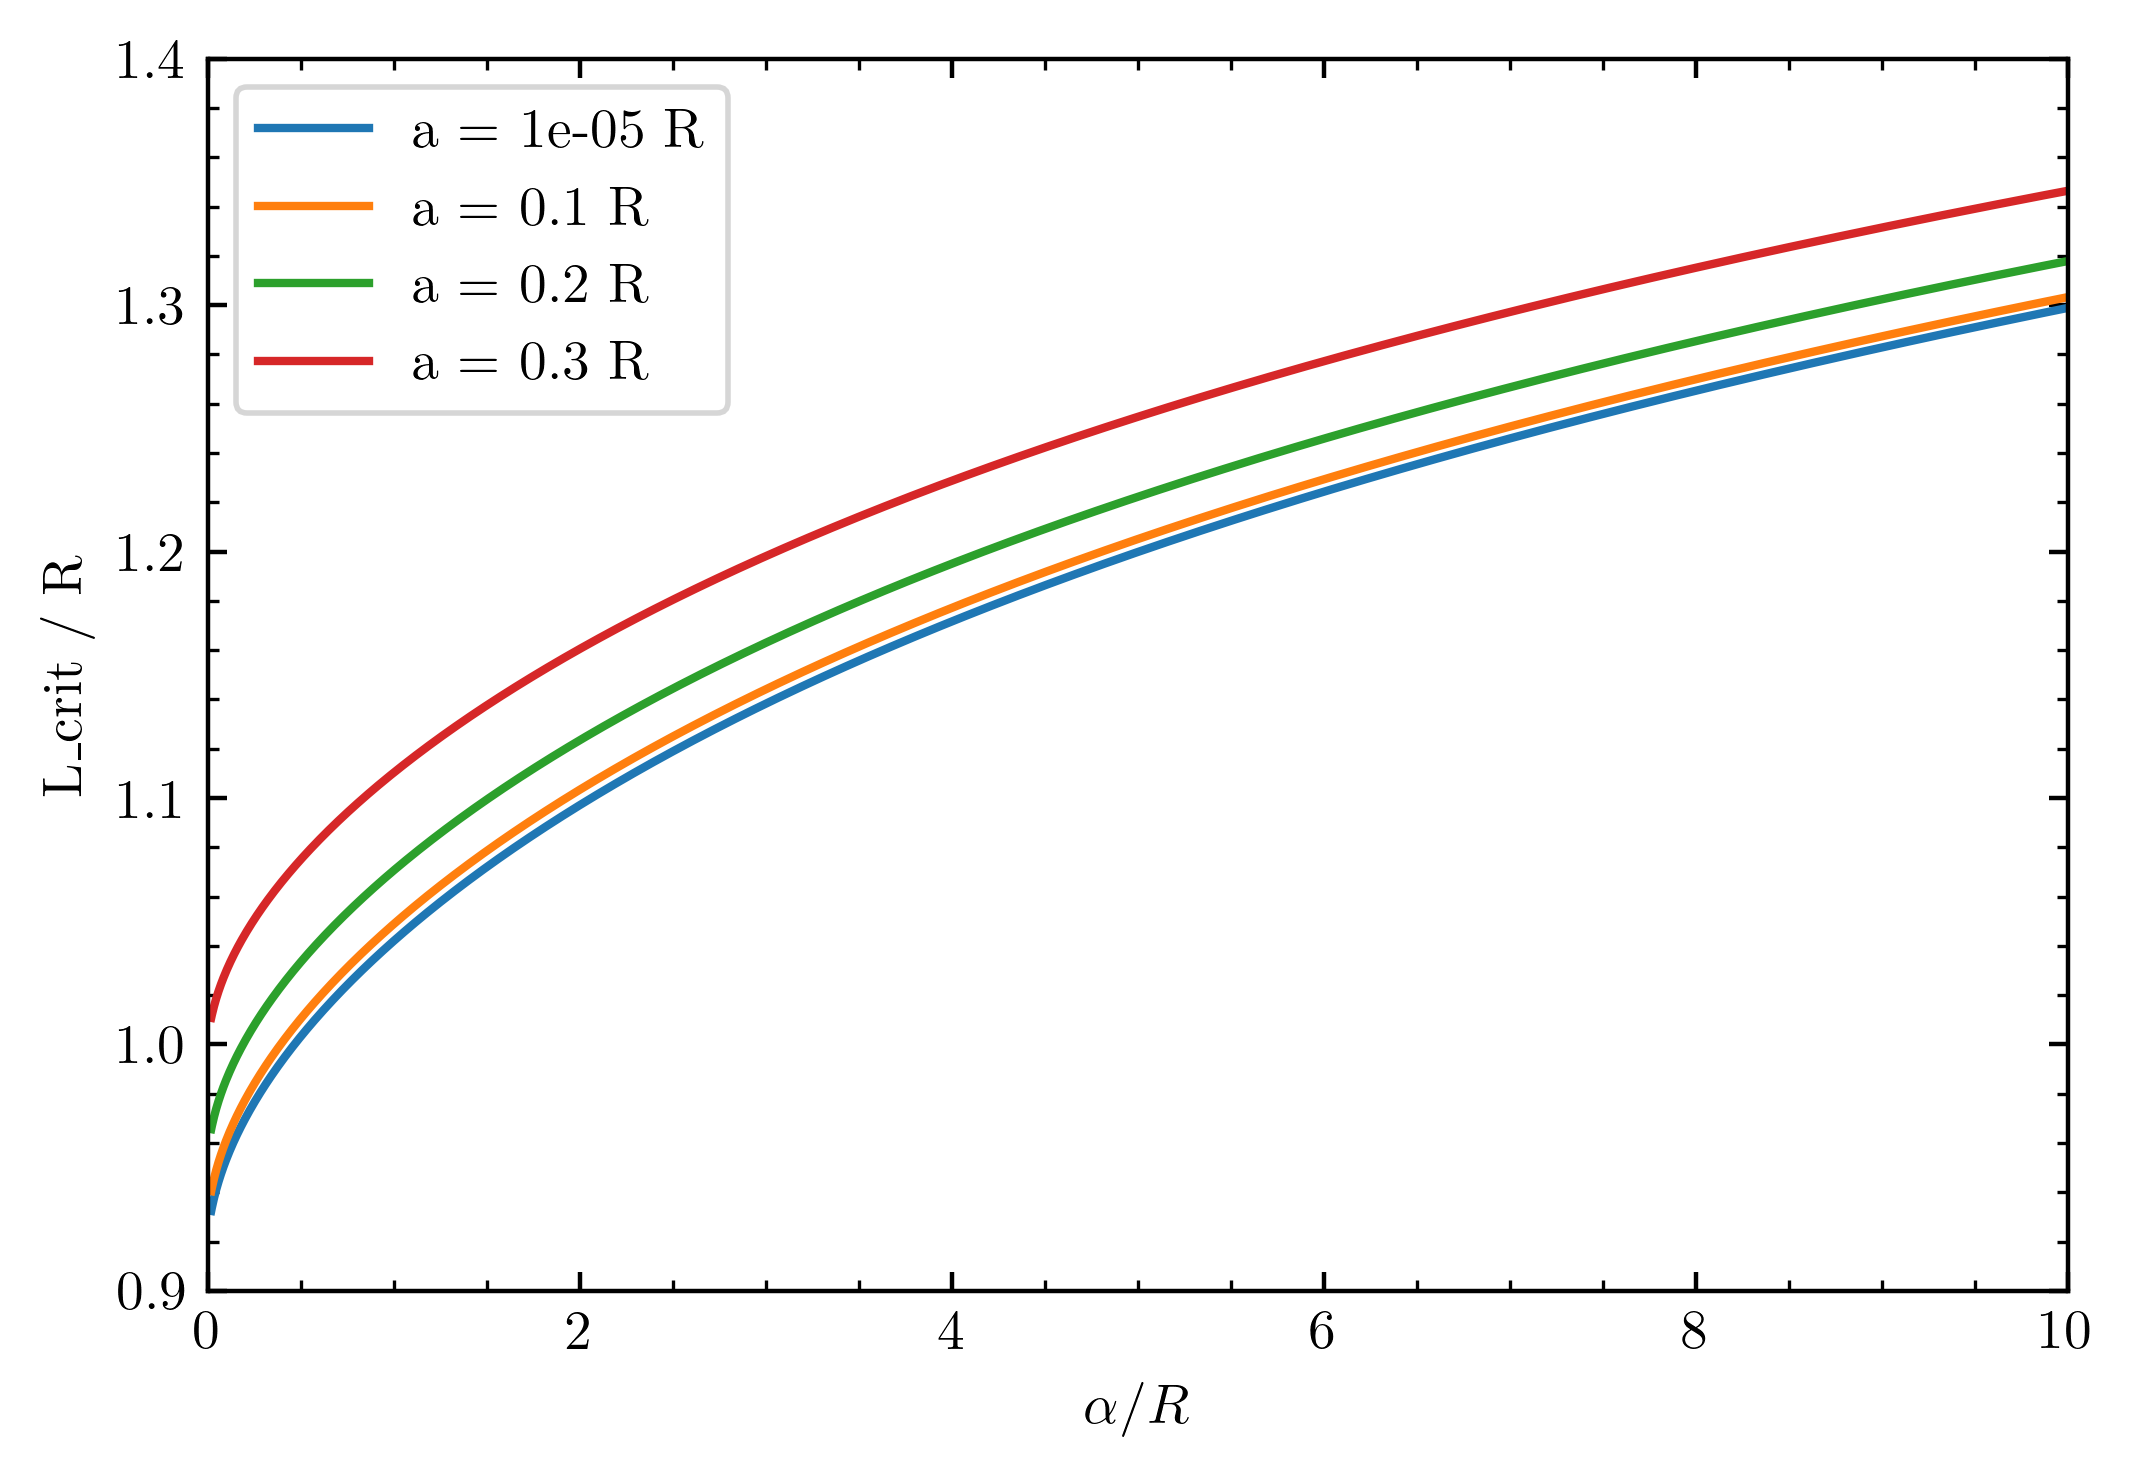

In [18]:
plt.plot(ncalphagrid[ncmask],climLCArr,label=f'a = {eps} R')
plt.plot(ncalphagrid[ncmask],ncLCArr,label='a = 0.1 R')
plt.plot(ncalphagrid[ncmask],ncLCArr2,label='a = 0.2 R')
plt.plot(ncalphagrid[ncmask],ncLCArr3,label='a = 0.3 R')
# plt.semilogx()
# plt.semilogy()
plt.xlim(0,10)
plt.ylim(0.9,1.4)
plt.xlabel(r'$\alpha / R$')
plt.ylabel(r'L_{crit} / R')
plt.legend()
# plt.show()
plt.savefig('combFigs/Lcrit.pdf',format='pdf')